<a href="https://colab.research.google.com/github/FossegrimRora/Subject-1/blob/main/Fathir_Putra_H.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [231]:
!pip install kaggle

In [232]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahdimashayekhi/disease-risk-from-daily-habits")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'disease-risk-from-daily-habits' dataset.
Path to dataset files: /kaggle/input/disease-risk-from-daily-habits


In [233]:
!pip install catboost

In [234]:
#import library
import pandas as pd
import os

# Lihat isi folder dataset
print(os.listdir(path))

['health_lifestyle_classification.csv']


In [235]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from catboost import CatBoostClassifier

In [236]:
df = pd.read_csv(path + "/health_lifestyle_classification.csv")
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,NaN,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,NaN,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,NaN,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,NaN,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,NaN,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   survey_code               100000 non-null  int64  
 1   age                       100000 non-null  int64  
 2   gender                    100000 non-null  object 
 3   height                    100000 non-null  float64
 4   weight                    100000 non-null  float64
 5   bmi                       100000 non-null  float64
 6   bmi_estimated             100000 non-null  float64
 7   bmi_scaled                100000 non-null  float64
 8   bmi_corrected             100000 non-null  float64
 9   waist_size                100000 non-null  float64
 10  blood_pressure            92331 non-null   float64
 11  heart_rate                85997 non-null   float64
 12  cholesterol               100000 non-null  float64
 13  glucose                   100000 non-null  fl

In [238]:
pd.set_option('display.max_columns', None)
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,mental_health_score,mental_health_support,education_level,job_type,occupation,income,diet_type,exercise_type,device_usage,healthcare_access,insurance,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,118.264254,60.749825,214.580523,103.008176,NaN,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,NaN,Non-smoker,1.694262,5.003963,2,8,No,PhD,Tech,Farmer,6759.821719,Vegan,Strength,High,Poor,No,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,9,No,High School,Office,Engineer,6240.517690,Vegan,Cardio,Moderate,Moderate,No,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,123.073698,76.043212,138.134787,89.180302,NaN,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,1,No,Master,Office,Teacher,3429.179266,Vegan,Cardio,High,Good,Yes,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,4,No,Master,Labor,Teacher,2618.503534,Vegetarian,Mixed,Low,Moderate,No,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,NaN,Heavy,1.968393,3.180087,9,7,Yes,Master,Unemployed,Doctor,3662.086276,Vegan,NaN,Low,Moderate,Yes,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


In [239]:
df.isnull().sum()

,0
survey_code,0
age,0
gender,0
height,0
weight,0
bmi,0
bmi_estimated,0
bmi_scaled,0
bmi_corrected,0
waist_size,0


In [240]:
df = df.drop(columns=[
'survey_code',
'bmi_estimated',
'bmi_scaled',
'bmi_corrected',
'mental_health_score',
'mental_health_support',
'education_level',
'job_type',
'occupation',
'income',
'healthcare_access',
'insurance',
'sunlight_exposure',
'family_history',
'pet_owner',
'electrolyte_level',
'gene_marker_flag',
'environmental_risk_score',
'daily_supplement_dosage'
])

df.columns

Index(['age', 'gender', 'height', 'weight', 'bmi', 'waist_size',
       'blood_pressure', 'heart_rate', 'cholesterol', 'glucose', 'insulin',
       'sleep_hours', 'sleep_quality', 'work_hours', 'physical_activity',
       'daily_steps', 'calorie_intake', 'sugar_intake', 'alcohol_consumption',
       'smoking_level', 'water_intake', 'screen_time', 'stress_level',
       'diet_type', 'exercise_type', 'device_usage', 'meals_per_day',
       'caffeine_intake', 'target'],
      dtype='object')

In [241]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [242]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
bmi,0
waist_size,0
blood_pressure,0
heart_rate,0
cholesterol,0
glucose,0


In [243]:
df['target'] = df['target'].map({
    'healthy':0,
    'diseased':1
})



df['target'].value_counts()

,count
target,
0,70097
1,29903


In [244]:
X = df.drop('target', axis=1)
y = df['target']

In [245]:
cat_features = X.select_dtypes(include='object').columns.tolist()

print(cat_features)

['gender', 'sleep_quality', 'alcohol_consumption', 'smoking_level', 'diet_type', 'exercise_type', 'device_usage', 'caffeine_intake']


In [246]:
df['insulin'] = df['insulin'].clip(lower=0)

In [247]:
df['sugar_intake'] = df['sugar_intake'].clip(lower=0)

In [248]:
df.describe()

,age,height,weight,bmi,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,water_intake,screen_time,stress_level,meals_per_day,target
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,48.525990,170.023707,70.064862,24.493876,84.933043,119.977974,74.979964,189.966438,99.994538,14.988967,7.002008,8.001331,3.038344,7012.206098,2201.428579,60.054597,2.006373,6.021525,4.991600,2.998720,0.299030
std,17.886768,9.982798,14.693667,5.951069,12.040314,14.428246,9.219394,29.981934,19.982828,4.584308,1.496821,1.994723,1.884475,2383.082319,400.516318,19.942291,0.688868,2.933835,3.154997,1.414786,0.457835
min,18.000000,140.000000,40.000000,9.988495,34.093185,59.128168,34.745092,58.410902,12.434931,0.000000,3.000000,0.000000,0.000000,1000.000000,527.172360,0.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,33.000000,163.306615,59.856938,20.271405,76.795185,110.815119,69.543894,169.667738,86.461401,12.324714,5.986781,6.651093,1.633799,5500.327842,1932.278165,46.504292,1.532011,3.971318,2.000000,2.000000,0.000000
50%,48.000000,170.016778,69.924141,24.156734,84.957139,119.951794,75.046211,190.044579,99.986834,14.983414,6.998164,8.004549,2.971222,7004.285450,2200.992765,60.047905,2.000659,5.991171,5.000000,3.000000,0.000000
75%,64.000000,176.728920,80.027418,28.258696,93.018713,129.185145,80.467128,210.222005,113.508722,17.663430,8.019219,9.353669,4.326500,8523.819577,2471.218160,73.476386,2.473047,8.024470,8.000000,4.000000,1.000000
max,79.000000,210.000000,139.250894,59.234792,133.153631,184.439195,114.136041,319.875613,183.883548,35.464749,12.000000,16.000000,11.631898,18064.969543,3949.019017,141.514522,5.000000,16.000000,10.000000,5.000000,1.000000


In [249]:
df['target'].value_counts()
auto_class_weights="Balanced"


In [250]:
pd.set_option('display.max_columns', None)
df.head()

,age,gender,height,weight,bmi,waist_size,blood_pressure,heart_rate,cholesterol,glucose,insulin,sleep_hours,sleep_quality,work_hours,physical_activity,daily_steps,calorie_intake,sugar_intake,alcohol_consumption,smoking_level,water_intake,screen_time,stress_level,diet_type,exercise_type,device_usage,meals_per_day,caffeine_intake,target
0,56,Male,173.416872,56.886640,18.915925,72.165130,118.264254,60.749825,214.580523,103.008176,14.983414,6.475885,Fair,7.671313,0.356918,13320.942595,2673.546960,44.476887,Unknown,Non-smoker,1.694262,5.003963,2,Vegan,Strength,High,5,Moderate,0
1,69,Female,163.207380,97.799859,36.716278,85.598889,117.917986,66.463696,115.794002,116.905134,10.131597,8.428410,Good,9.515198,0.568219,11911.201401,2650.376972,74.663405,Regularly,Light,0.716409,5.925455,3,Vegan,Cardio,Moderate,5,High,0
2,46,Male,177.281966,80.687562,25.673050,90.295030,123.073698,76.043212,138.134787,89.180302,14.983414,5.702164,Poor,5.829853,3.764406,2974.035375,1746.755144,19.702382,Regularly,Heavy,2.487900,4.371250,0,Vegan,Cardio,High,4,Moderate,0
3,32,Female,172.101255,63.142868,21.318480,100.504211,148.173453,68.781981,203.017447,128.375798,18.733179,5.188316,Good,9.489693,0.889474,5321.539497,2034.193242,82.580050,Occasionally,Heavy,2.643335,4.116064,10,Vegetarian,Mixed,Low,1,Unknown,0
4,60,Female,163.608816,40.000000,14.943302,69.021150,150.613181,92.335358,200.412439,94.813332,16.038701,7.912514,Good,7.275450,2.901608,9791.376712,2386.210257,45.961322,Unknown,Heavy,1.968393,3.180087,9,Vegan,Unknown,Low,1,High,0


In [251]:
df.isnull().sum()

,0
age,0
gender,0
height,0
weight,0
bmi,0
waist_size,0
blood_pressure,0
heart_rate,0
cholesterol,0
glucose,0


In [252]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", auc)

ROC AUC: 0.5038401379435383


In [253]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[7322 6697]
 [3080 2901]]


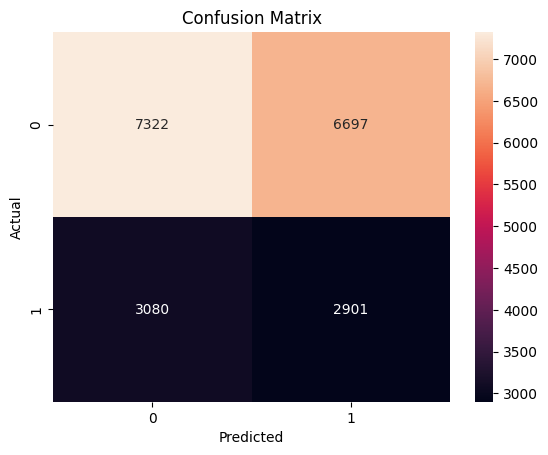

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [255]:
import numpy as np

y_pred_new = (y_prob > 0.3).astype(int)

In [256]:
import numpy as np

print("Prediksi:", np.unique(y_pred_new, return_counts=True))

Prediksi: (array([1]), array([20000]))


In [257]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_new, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     14019
           1       0.30      1.00      0.46      5981

    accuracy                           0.30     20000
   macro avg       0.15      0.50      0.23     20000
weighted avg       0.09      0.30      0.14     20000



In [258]:
y_prob = model.predict_proba(X_test)[:,1]
y_pred_new = (y_prob > 0.3).astype(int)

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     14019
           1       0.30      1.00      0.46      5981

    accuracy                           0.30     20000
   macro avg       0.15      0.50      0.23     20000
weighted avg       0.09      0.30      0.14     20000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


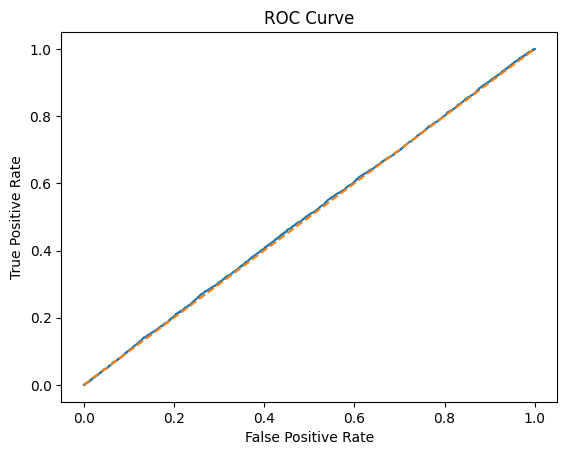

In [259]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [260]:
# Kombinasi fitur penting
df["bmi_age"] = df["bmi"] * df["age"]
df["glucose_cholesterol"] = df["glucose"] * df["cholesterol"]
df["bp_age"] = df["blood_pressure"] * df["age"]
df["activity_score"] = df["daily_steps"] * df["physical_activity"]

# Risk score sederhana
df["health_risk"] = (
    df["bmi"] +
    df["glucose"] +
    df["cholesterol"] +
    df["blood_pressure"]
)

In [261]:
drop_features = [
    'sleep_quality',
    'caffeine_intake',
    'diet_type',
    'exercise_type',
    'device_usage',
    'smoking_level'
]

df = df.drop(columns=drop_features)

In [262]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [263]:
cat_features = X.select_dtypes(include='object').columns.tolist()

In [264]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=10,
    random_strength=1,
    bagging_temperature=1,
    auto_class_weights="Balanced",
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=200
)

In [265]:
df["lifestyle_risk"] = (
    df["sugar_intake"] +
    df["screen_time"] -
    df["physical_activity"]
)

In [266]:


from sklearn.preprocessing import StandardScaler

num_cols = X.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [267]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=200
)

0:	learn: 0.5217405	test: 0.4997830	best: 0.4997830 (0)	total: 289ms	remaining: 14m 26s
200:	learn: 0.7019696	test: 0.4986580	best: 0.5036625 (2)	total: 40.1s	remaining: 9m 17s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5036624507
bestIteration = 2

Shrink model to first 3 iterations.


CatBoostClassifier(auto_class_weights='Balanced', bagging_temperature=1, depth=8, eval_metric='Accuracy', iterations=3000, l2_leaf_reg=10, learning_rate=0.03, loss_function='Logloss', random_state=42, random_strength=1, verbose=200)

In [268]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.51115
              precision    recall  f1-score   support

           0       0.70      0.52      0.60     14019
           1       0.30      0.49      0.37      5981

    accuracy                           0.51     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.58      0.51      0.53     20000

